In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [11]:
using Revise
includet("./base.jl")
using Printf
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [3]:
includet("../../../scripts/figures_util.jl")

using CairoMakie
CairoMakie.activate!()

# Data

`gd2_B5_260824_2193.jld2` is `gendata2()` - `B=5`, 30 leakages (0.5 to 0.999) x 50 Ks x 100
repeats. The file is ~11 GB and `make_Kli_matrix` pulls all of `raw_dfs` into memory.

In [4]:
f = jldopen("./gd2_B5_260824_2193.jld2")
@show f["N"] f["M"] f["B"] f["DN"] f["DR"] f["num_repeats"];

f["N"] = 20
f["M"] = 20
f["B"] = 5
f["DN"] = 0.0
f["DR"] = 1.0
f["num_repeats"] = 100

In [5]:
@time Ks, lis, rslts = make_Kli_matrix(f);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01

 54.961270 seconds (45.06 M allocations: 11.967 GiB, 37.86% gc time, 7.63% compilation time: 17% of which was recompilation)

# Dominant outcome phase diagram

Each point is one (K, l) cell coloured by whichever of extinct / non-extinct unstable /
non-extinct stable was the most common over the 100 repeats. Solid line is the fr3
extinction boundary at `gamma = d / c`, dashed is the fr_cor1 instability boundary at p=1.
`d = 1 / B` as in the paper figure.

In [6]:
function dominant_colors(rslts)
    map(rslts) do x
        am = argmax([x.extinct, x.nonext_unstable, x.nonext_stable])
        if am == 1
            PaperColors.extinct()
        elseif am == 2
            PaperColors.unstable()
        else
            PaperColors.stable()
        end
    end
end

dominant_colors (generic function with 1 method)

In [12]:
function plot_dominant(Ks, lis, rslts; p=1.0, d=1.0, title="")
    dominant = dominant_colors(rslts)
    leakxs = LeakageScale.ltox.(lis)

    # l = 1 is at infinity on this scale, drop it if it is in the grid
    keep = isfinite.(leakxs)
    leakxs = leakxs[keep]
    dominant = dominant[:, keep]

    fig = Figure()
    ax = Axis(fig[1, 1];
        title,
        xscale=log10,
        xlabel="Normalized energy supply rate K",
        ylabel="Supplied resource leakage l",
        xticks=log10ticks(-1:4),
        xminorticksvisible=true,
        xminorticks=IntervalsBetween(10),
        yminorticksvisible=true,
    )

    eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
    ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1 - e)) for e in eps_ticks])
    ax.yminorticks = LeakageScale.exminorticks(eps_ticks, 4)

    scatter!(ax, [(x, y) for x in Ks for y in leakxs];
        markersize=6,
        color=dominant'[:],
    )

    # pad the limits by half a grid step so the edge markers are not cut in half
    lKs = log10.(Ks)
    xlim_lo = 10^(lKs[1] - (lKs[2] - lKs[1]) / 2)
    xlim_hi = 10^(lKs[end] + (lKs[end] - lKs[end-1]) / 2)
    dy = minimum(diff(sort(leakxs)))
    ylim_lo = minimum(leakxs) - dy / 2
    ylim_hi = maximum(leakxs) + dy / 2

    thr_leakxs = range(ylim_lo, ylim_hi, 1000)
    thr_ls = LeakageScale.l.(thr_leakxs)
    # m = c = r = 1 throughout, so K = beta and gamma = d / c = d
    lines!(ax, MinimalModelV3.fr3_beta1.(thr_ls, d), thr_leakxs;
        color=:black,
    )
    # no fr3 version of the instability line, this one still assumes d = c
    lines!(ax, MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1.0, 1.0, p), thr_leakxs;
        color=:black,
        linestyle=:dash,
    )

    xlims!(ax, xlim_lo, xlim_hi)
    ylims!(ax, ylim_lo, ylim_hi)

    Legend(fig[1, 2],
        [MarkerElement(; color=c, marker=:circle) for c in
         [PaperColors.extinct(), PaperColors.unstable(), PaperColors.stable()]],
        ["extinct", "unstable", "stable"],
    )

    fig
end

plot_dominant (generic function with 1 method)

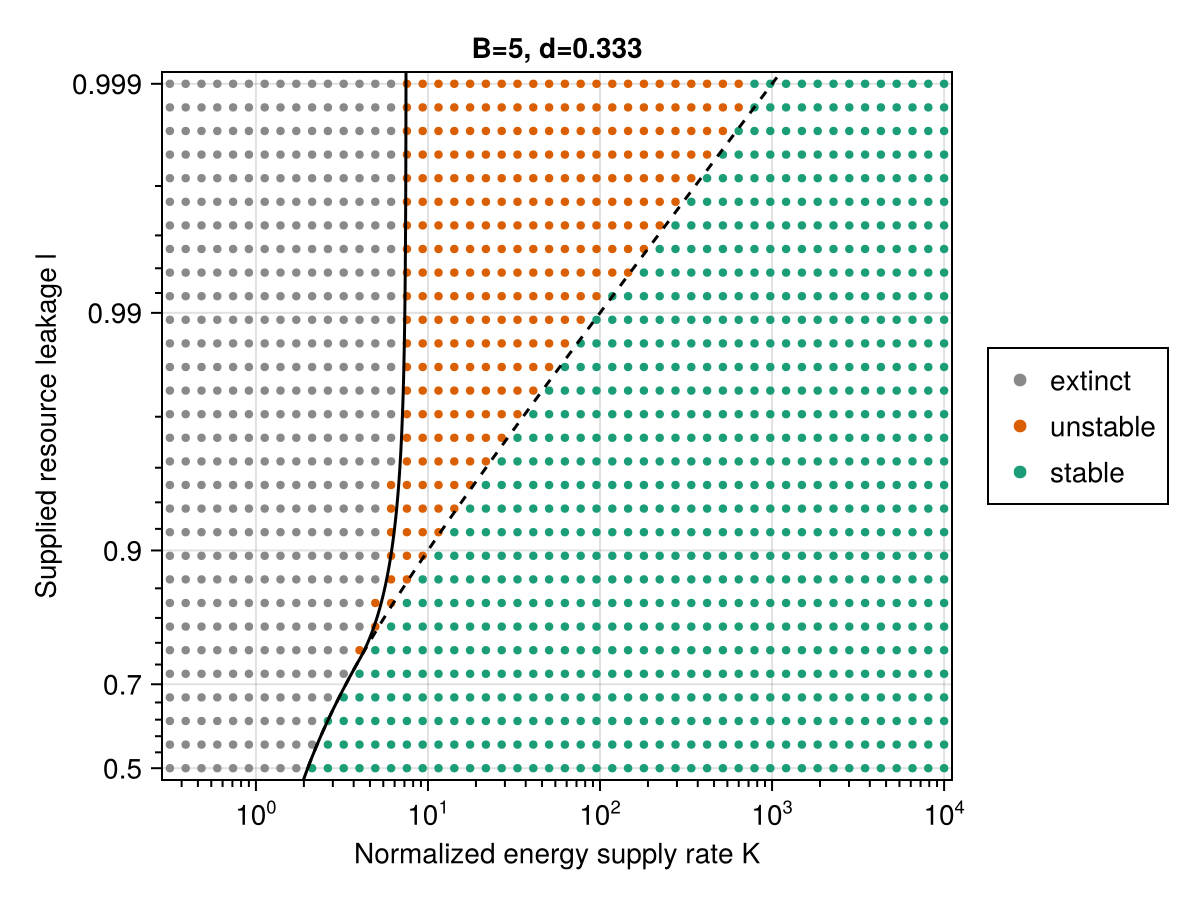

In [23]:
d = 1 / 3
f = plot_dominant(Ks, lis, rslts; d, title=(@sprintf "B=5, d=%.3g" d))
Makie.save("pd_B5.pdf", f)
f

# The same for the B=3 run

`gd1_260731_115325.jld2` is `gendata1()` from before the `lis` override was removed, so `B=3`
and only 5 leakages (1.0, 0.999, 0.99, 0.9, 0.75). `l=1` is dropped as it is at infinity on
this axis.

In [9]:
f3 = jldopen("./gd1_260731_115325.jld2")
@time Ks3, lis3, rslts3 = make_Kli_matrix(f3);

  9.565661 seconds (6.85 M allocations: 1.944 GiB, 16.64% gc time)

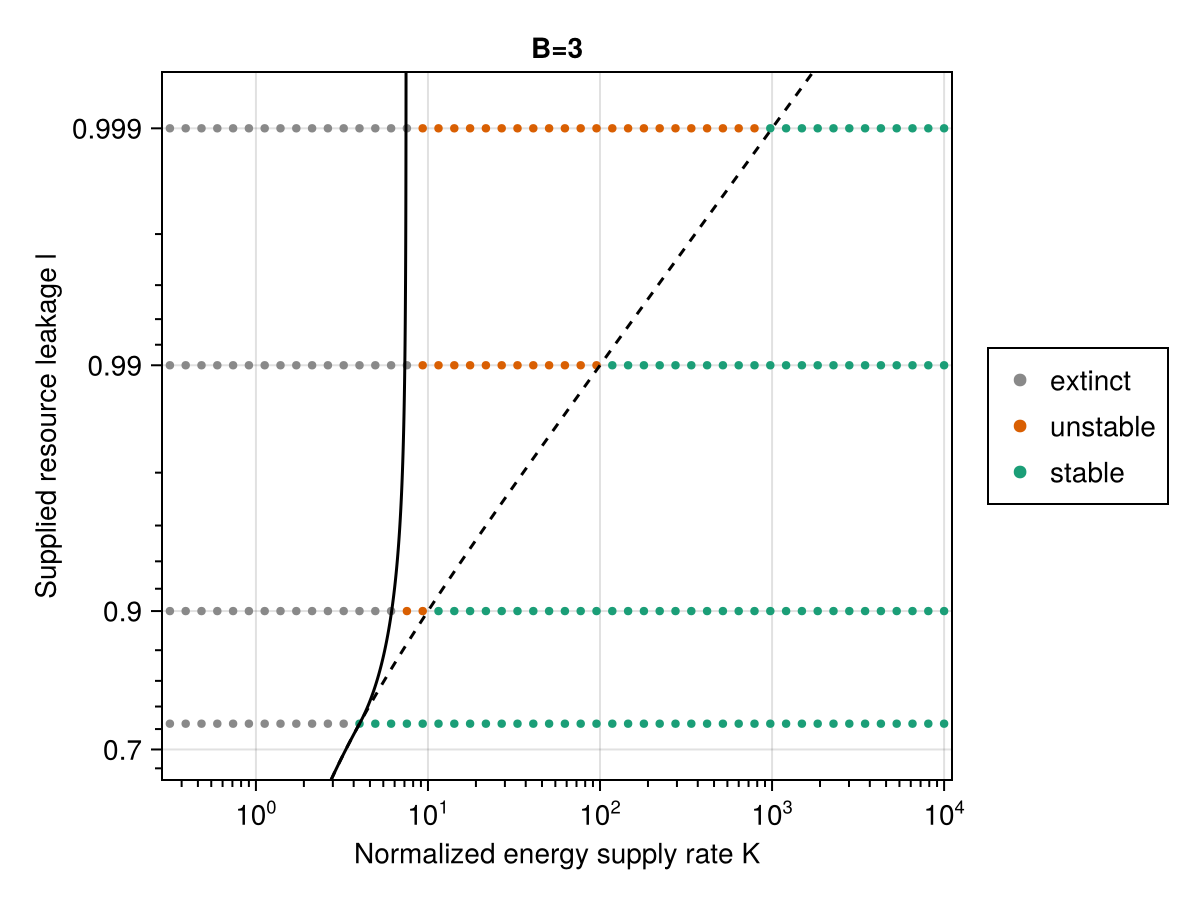

In [16]:
plot_dominant(Ks3, lis3, rslts3; d=1 / 3, title="B=3")